In [76]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# Add project root to path
sys.path.append(str(Path("..").resolve()))

# Laden von trainierten Modellen


In [77]:
from helpers import load_fitted_model

model_configurations = [
    ("hmm", 2, 42),
    ("hmm", 3, 42),
    ("hmm", 4, 42),  # Konfigurationen mit Seed 42
    ("vdhmm", 2, 42),
    ("vdhmm", 3, 42),
    ("vdhmm", 4, 42),
    ("hmm", 2, 43),
    ("hmm", 3, 43),
    ("hmm", 4, 43),
    ("vdhmm", 2, 43),
    ("vdhmm", 3, 43),  # Konfigurationen mit Seed 43
    ("vdhmm", 4, 43),
    ("hmm", 2, 123),
    ("hmm", 3, 123),
    ("hmm", 4, 123),  # Konfigrationen mit Seed 123
    ("vdhmm", 2, 123),
    ("vdhmm", 3, 123),
    ("vdhmm", 4, 123),
    ("hmm", 2, None),  # Konfiguration mit Seed None (Original Indizes)
    ("hmm", 3, None),
    ("hmm", 4, None),
    ("vdhmm", 2, None),  # Konfiguration mit Seed None (Original Indizes)
    ("vdhmm", 3, None),
    ("vdhmm", 4, None),
]

n_models = len(model_configurations)

# get different metrics out of hmm models

results_df = pd.DataFrame(
    {
        "Model": [
            f"{model_name}_{S}" for (model_name, S, seed) in model_configurations
        ],
        "Seed": [
            seed if seed else "Original"
            for (model_name, S, seed) in model_configurations
        ],
        # "LOOIC": [0.0] * n_models,
        # "WAIC": [0.0] * n_models,
        # "LPD_TRAIN": [0.0] * n_models,
        # "LPD_VAL": [0.0] * n_models,
        "AUC_TRAIN": [0.0] * n_models,
        "AUC_TEST": [0.0] * n_models,
        "R_HAT_MEAN": [0.0] * n_models,
        "R_HAT_STD": [0.0] * n_models,
    }
)

In [78]:
import arviz as az
from sklearn.metrics import roc_auc_score
import warnings

from constants import PROCESSED_DATA_FOLDER
from helpers import ModelData

# Unterdrücke ArviZ Warnungen und Output
warnings.filterwarnings("ignore")

# Schleife über alle Modell-Konfigurationen
for k, (model_name, S, seed) in enumerate(model_configurations):
    print(f"Processing {k+1}/{n_models}: {model_name} with {S} states (seed={seed})...")
    model_data = ModelData.from_pickle(
        PROCESSED_DATA_FOLDER / f"processed_data_{seed if seed else "original"}.pkl"
    )
    eval_indices = model_data.eval_indices

    # get original eval indices for each seed
    np.random.seed(seed)
    indices_val_cal = np.random.permutation(np.arange(500, 921))

    # Lade das Modell mit Seed
    try:
        model = load_fitted_model(model_name, S, seed=seed)
    except FileNotFoundError:
        print(
            f"FileNotFound: {model_name} with {S} states and seed {seed} was not found! Skipping..."
        )
        continue

    log_lik = model.fit.stan_variable("log_lik")
    log_lik_test = model.fit.stan_variable("log_lik_test")
    close_prob = model.fit.stan_variable("close_prob")
    close_prob_mean = close_prob.mean(axis=0)

    idata = az.from_cmdstanpy(model.fit, log_likelihood="log_lik")

    # Berechne AUC für Trainingsdaten (in Prozent)
    y_true_train = np.array(model.stan_data["Closed"][:500])
    results_df.loc[k, "AUC_TRAIN"] = 100 * roc_auc_score(
        y_true_train, close_prob_mean[:500]
    )

    y_true_test = np.array(model.stan_data["Closed"])[eval_indices]
    # Annahme: Die Schrittweite passt, ggf. muss die Dimensionalität geprüft werden!
    close_prob_test_mean = np.mean(model.fit.stan_variable("close_prob"), axis=0)
    results_df.loc[k, "AUC_TEST"] = 100 * roc_auc_score(
        y_true_test, close_prob_mean[eval_indices]
    )

    # Verwende das bereits gespeicherte summary DataFrame (bereits in model.summary!)
    # Berechne Durchschnitt und Standardabweichung von R_hat über alle Parameter
    results_df.loc[k, "R_HAT_MEAN"] = np.nanmean(model.summary["R_hat"])
    results_df.loc[k, "R_HAT_STD"] = np.nanstd(model.summary["R_hat"])

print("\nErgebnisse:")

# Ergebnisse runden
results_df["AUC_TRAIN"] = results_df["AUC_TRAIN"].round(2)
results_df["AUC_TEST"] = results_df["AUC_TEST"].round(2)
results_df["R_HAT_MEAN"] = results_df["R_HAT_MEAN"].round(4)
results_df["R_HAT_STD"] = results_df["R_HAT_STD"].round(4)


np.random.seed(None)

results_df

Processing 1/24: hmm with 2 states (seed=42)...
Processing 2/24: hmm with 3 states (seed=42)...
Processing 3/24: hmm with 4 states (seed=42)...
Processing 4/24: vdhmm with 2 states (seed=42)...
Processing 5/24: vdhmm with 3 states (seed=42)...
Processing 6/24: vdhmm with 4 states (seed=42)...
Processing 7/24: hmm with 2 states (seed=43)...
Processing 8/24: hmm with 3 states (seed=43)...
Processing 9/24: hmm with 4 states (seed=43)...
Processing 10/24: vdhmm with 2 states (seed=43)...
Processing 11/24: vdhmm with 3 states (seed=43)...
Processing 12/24: vdhmm with 4 states (seed=43)...
Processing 13/24: hmm with 2 states (seed=123)...
Processing 14/24: hmm with 3 states (seed=123)...
Processing 15/24: hmm with 4 states (seed=123)...
FileNotFound: hmm with 4 states and seed 123 was not found! Skipping...
Processing 16/24: vdhmm with 2 states (seed=123)...
Processing 17/24: vdhmm with 3 states (seed=123)...
Processing 18/24: vdhmm with 4 states (seed=123)...
Processing 19/24: hmm with 2 st

,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,hmm_2,42,79.86,78.44,1.0006,0.0007
1,hmm_3,42,83.83,81.34,1.3394,0.2104
2,hmm_4,42,83.60,80.78,1.6289,0.4337
3,vdhmm_2,42,79.26,78.32,1.3574,0.2292
4,vdhmm_3,42,85.36,83.27,1.0010,0.0009
5,vdhmm_4,42,85.78,83.72,1.5874,0.3723
6,hmm_2,43,82.24,73.80,1.0006,0.0007
7,hmm_3,43,84.48,79.44,1.3344,0.2133
8,hmm_4,43,85.90,80.74,1.2905,0.2101
9,vdhmm_2,43,82.85,72.32,1.0008,0.0008


In [79]:
# Split results for different seeds
grouped_dfs = {}

for seed, group_df in results_df.groupby("Seed"):
    grouped_dfs[seed] = group_df.copy()

print("\n" + "=" * 60)
print("SEED 42:")
print(60 * "=")
display(grouped_dfs[42])


print("\n" + "=" * 60)
print("SEED 43:")
print(60 * "=")
display(grouped_dfs[43])


print("\n" + "=" * 60)
print("SEED 123:")
print(60 * "=")
display(grouped_dfs[123])

print("\n" + "=" * 60)
print("ORIGINAL INDICES")
print(60 * "=")
display(grouped_dfs["Original"])


SEED 42:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,hmm_2,42,79.86,78.44,1.0006,0.0007
1,hmm_3,42,83.83,81.34,1.3394,0.2104
2,hmm_4,42,83.60,80.78,1.6289,0.4337
3,vdhmm_2,42,79.26,78.32,1.3574,0.2292
4,vdhmm_3,42,85.36,83.27,1.0010,0.0009
5,vdhmm_4,42,85.78,83.72,1.5874,0.3723



SEED 43:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
6,hmm_2,43,82.24,73.80,1.0006,0.0007
7,hmm_3,43,84.48,79.44,1.3344,0.2133
8,hmm_4,43,85.90,80.74,1.2905,0.2101
9,vdhmm_2,43,82.85,72.32,1.0008,0.0008
10,vdhmm_3,43,86.14,83.52,1.0019,0.0017
11,vdhmm_4,43,86.32,81.18,1.7999,0.5237



SEED 123:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
12,hmm_2,123,78.44,75.11,1.3746,0.2151
13,hmm_3,123,82.20,77.15,1.4801,0.2884
14,hmm_4,123,0.00,0.00,0.0000,0.0000
15,vdhmm_2,123,78.21,74.93,1.0009,0.0008
16,vdhmm_3,123,84.19,79.99,1.7911,0.4310
17,vdhmm_4,123,84.19,80.52,1.4819,0.3928



ORIGINAL INDICES


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
18,hmm_2,Original,78.53,77.14,1.0010,0.0011
19,hmm_3,Original,81.81,82.39,1.3345,0.2149
20,hmm_4,Original,82.68,83.71,1.6543,0.4159
21,vdhmm_2,Original,78.27,76.40,1.3539,0.2286
22,vdhmm_3,Original,83.93,84.39,1.0007,0.0008
23,vdhmm_4,Original,82.99,83.48,1.6784,0.4346


# Robustness Analysis: Seed Variability

---

## Statistische Analyse der Model-Robustheit

Analyse der Performance-Stabilität der HMM und VDHMM Modelle über verschiedene Seeds hinweg


In [80]:
# Filter: Nur numerische Seeds (keine "Original" und kein fehlgeschlagenes hmm_4 mit seed=123)
robustness_df = results_df[
    ~((results_df["Model"] == "hmm_4") & (results_df["Seed"] == 123))
].copy()

# Teile Modellname (HMM_2) in Modeltyp (HMM) und Anzahl Zustände (2)
robustness_df["Model_Type"] = robustness_df["Model"].str.split("_").str[0].str.upper()
robustness_df["States"] = robustness_df["Model"].str.split("_").str[1].astype(int)


print("=" * 110)
print("HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)")
print("=" * 110)
print(
    robustness_df[
        ["Model_Type", "States", "Seed", "AUC_TRAIN", "AUC_TEST", "R_HAT_MEAN"]
    ].to_string(index=False)
)

# Berechne Statistiken pro Modellkonfiguration
robustness_stats = (
    robustness_df.groupby(["Model_Type", "States"])
    .agg(
        {
            "AUC_TEST": ["mean", "std", "min", "max"],
            "AUC_TRAIN": ["mean", "std"],
            "R_HAT_MEAN": ["mean", "max"],
        }
    )
    .round(2)
)

# Flatten multi-level columns
robustness_stats.columns = [
    "_".join(col).strip() for col in robustness_stats.columns.values
]
robustness_stats = robustness_stats.reset_index()

# Berechne Coefficient of Variation (CV) für AUC_TEST in Prozent
robustness_stats["AUC_TEST_CV_%"] = (
    robustness_stats["AUC_TEST_std"] / robustness_stats["AUC_TEST_mean"] * 100
).round(2)

# Berechne Range für AUC_TEST
robustness_stats["AUC_TEST_Range"] = (
    robustness_stats["AUC_TEST_max"] - robustness_stats["AUC_TEST_min"]
).round(2)

print("\n" + "=" * 110)
print("ROBUSTNESS STATISTICS: Mean ± Std across Seeds")
print("=" * 110)
print(robustness_stats.to_string(index=False))

# Identifiziere die robustesten Modelle (niedrigster CV%)
print("\n" + "=" * 110)
print("ROBUSTNESS RANKING (by Coefficient of Variation)")
print("=" * 110)
robustness_ranking = robustness_stats.sort_values("AUC_TEST_CV_%")
print(
    robustness_ranking[
        [
            "Model_Type",
            "States",
            "AUC_TEST_mean",
            "AUC_TEST_std",
            "AUC_TEST_CV_%",
            "AUC_TEST_Range",
        ]
    ].to_string(index=False)
)

HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)
Model_Type  States     Seed  AUC_TRAIN  AUC_TEST  R_HAT_MEAN
       HMM       2       42      79.86     78.44      1.0006
       HMM       3       42      83.83     81.34      1.3394
       HMM       4       42      83.60     80.78      1.6289
     VDHMM       2       42      79.26     78.32      1.3574
     VDHMM       3       42      85.36     83.27      1.0010
     VDHMM       4       42      85.78     83.72      1.5874
       HMM       2       43      82.24     73.80      1.0006
       HMM       3       43      84.48     79.44      1.3344
       HMM       4       43      85.90     80.74      1.2905
     VDHMM       2       43      82.85     72.32      1.0008
     VDHMM       3       43      86.14     83.52      1.0019
     VDHMM       4       43      86.32     81.18      1.7999
       HMM       2      123      78.44     75.11      1.3746
       HMM       3      123      82.20     77.15      1.4801
     VDHMM       2      123      78.21  

## Visualisierung: Seed Variability


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setze Seaborn Style
sns.set_style("whitegrid")

### 1. Boxplot: AUC Test Distribution across Seeds

**Interpretation:**

- Boxes show the distribution of AUC values across different seeds
- Black line = Median, blue dashed line = Mean
- Smaller boxes = more robust models (less variability)


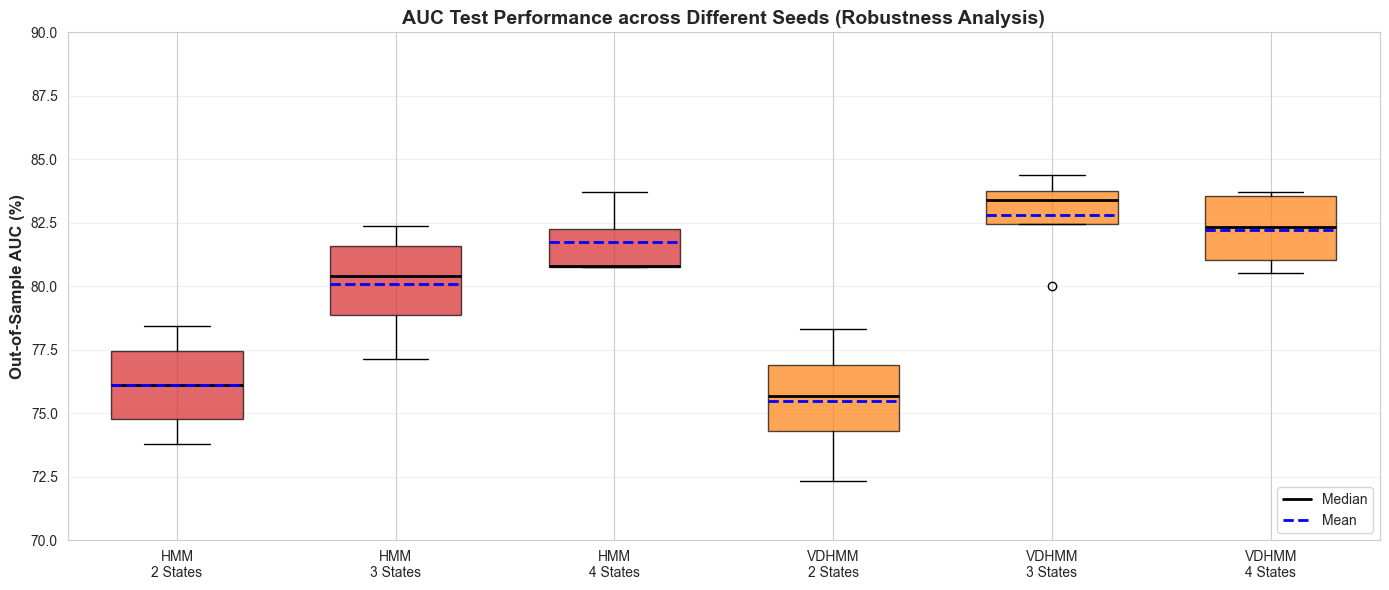

In [82]:
# Colors for HMM and VDHMM
colors = {"HMM": "#d62728", "VDHMM": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for boxplot
box_data = []
box_labels = []
box_colors = []

for model_type in ["HMM", "VDHMM"]:
    for states in [2, 3, 4]:
        data = robustness_df[
            (robustness_df["Model_Type"] == model_type)
            & (robustness_df["States"] == states)
        ]["AUC_TEST"].values

        if len(data) > 0:  # Only if data exists
            box_data.append(data)
            box_labels.append(f"{model_type}\n{states} States")
            box_colors.append(colors[model_type])

bp = ax.boxplot(
    box_data,
    labels=box_labels,
    patch_artist=True,
    widths=0.6,
    showmeans=True,
    meanline=True,
    medianprops=dict(color="black", linewidth=2),
    meanprops=dict(color="blue", linewidth=2, linestyle="--"),
)

# Color the boxes
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Out-of-Sample AUC (%)", fontsize=12, fontweight="bold")
ax.set_title(
    "AUC Test Performance across Different Seeds (Robustness Analysis)",
    fontsize=14,
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim([70, 90])

# Legend for mean vs median
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="black", linewidth=2, label="Median"),
    Line2D([0], [0], color="blue", linewidth=2, linestyle="--", label="Mean"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

### 2. Mean AUC Test with Standard Deviation (Error Bars)

**Interpretation:**

- Bars show the mean AUC across all seeds
- Error bars show the standard deviation
- Smaller error bars = higher robustness


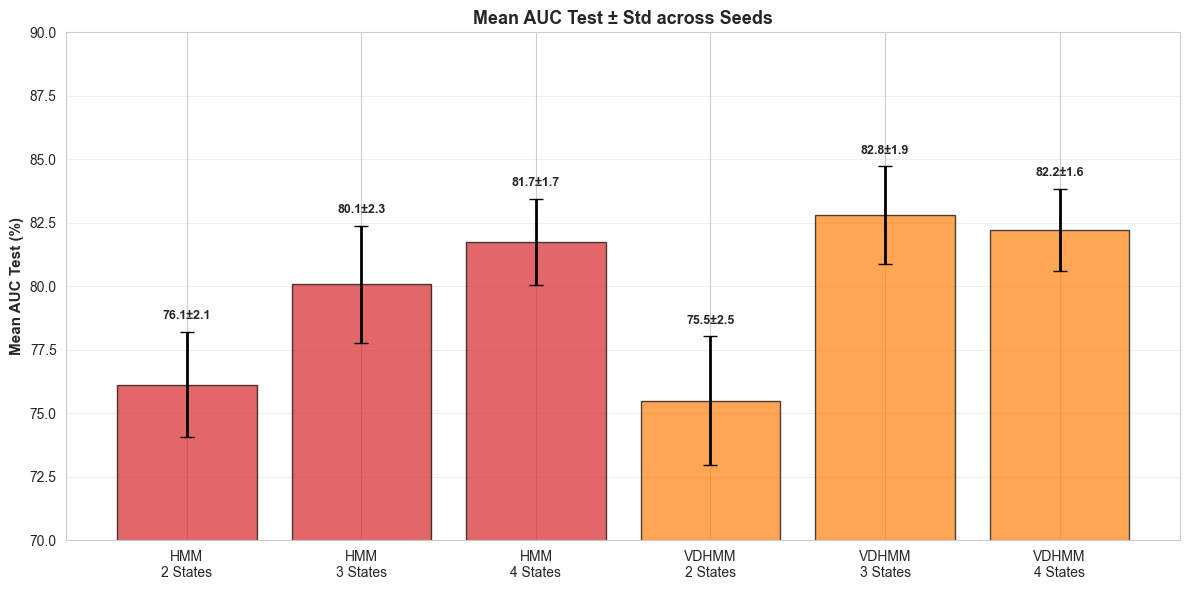

In [83]:
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(robustness_stats))
bar_colors = [colors[mt] for mt in robustness_stats["Model_Type"]]

bars = ax.bar(
    x_pos,
    robustness_stats["AUC_TEST_mean"],
    yerr=robustness_stats["AUC_TEST_std"],
    color=bar_colors,
    alpha=0.7,
    edgecolor="black",
    capsize=5,
    error_kw={"linewidth": 2},
)

ax.set_ylabel("Mean AUC Test (%)", fontsize=11, fontweight="bold")
ax.set_title("Mean AUC Test ± Std across Seeds", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [
        f"{row['Model_Type']}\n{row['States']} States"
        for _, row in robustness_stats.iterrows()
    ],
    fontsize=10,
)
ax.set_ylim([70, 90])
ax.grid(axis="y", alpha=0.3)

# Values above bars
for i, (mean, std) in enumerate(
    zip(robustness_stats["AUC_TEST_mean"], robustness_stats["AUC_TEST_std"])
):
    ax.text(
        i,
        mean + std + 0.5,
        f"{mean:.1f}±{std:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### 3. Coefficient of Variation (CV%) - Robustness Ranking

**Interpretation:**

- Coefficient of Variation (CV%) = Standard Deviation / Mean × 100
- Lower CV% = more robust model (less relative variability)
- CV% < 3% is considered very robust (which would mean a difference of ±2.5%)


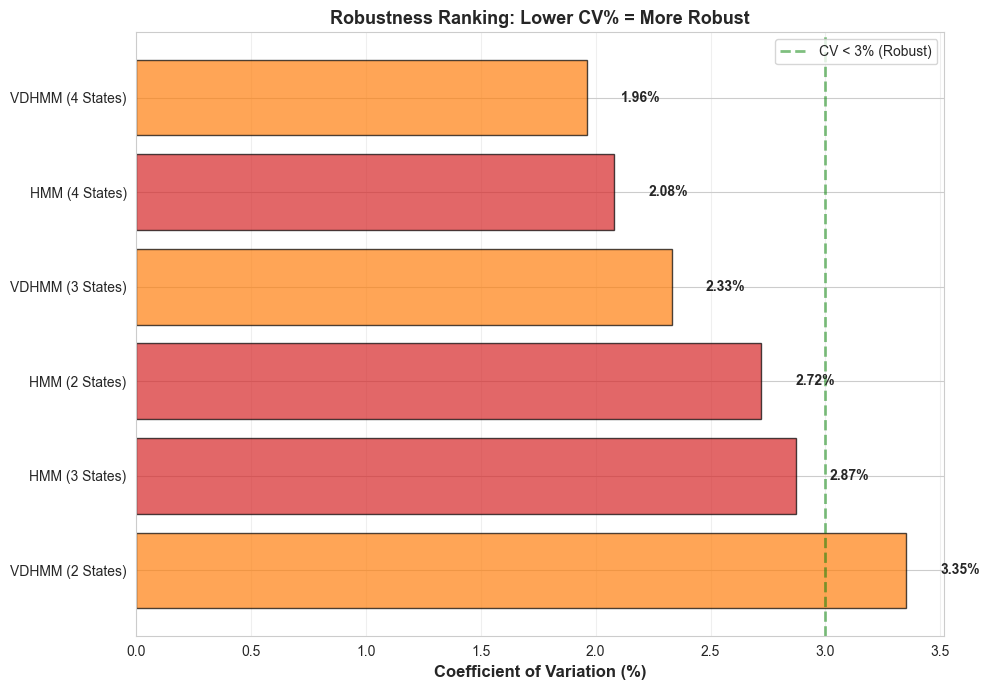

In [84]:
fig, ax = plt.subplots(figsize=(10, 7))

cv_sorted = robustness_stats.sort_values("AUC_TEST_CV_%")
x_pos = np.arange(len(cv_sorted))
bar_colors = [colors[mt] for mt in cv_sorted["Model_Type"]]

bars = ax.barh(
    x_pos, cv_sorted["AUC_TEST_CV_%"], color=bar_colors, alpha=0.7, edgecolor="black"
)

ax.set_xlabel("Coefficient of Variation (%)", fontsize=12, fontweight="bold")
ax.set_title(
    "Robustness Ranking: Lower CV% = More Robust", fontsize=13, fontweight="bold"
)
ax.set_yticks(x_pos)
ax.set_yticklabels(
    [
        f"{row['Model_Type']} ({row['States']} States)"
        for _, row in cv_sorted.iterrows()
    ],
    fontsize=10,
)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

# Values next to bars
for i, cv in enumerate(cv_sorted["AUC_TEST_CV_%"]):
    ax.text(cv + 0.15, i, f"{cv:.2f}%", va="center", fontsize=10, fontweight="bold")

# Mark highly robust models (CV < 3%)
ax.axvline(
    x=3,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label="CV < 3% (Robust)",
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 4. Heatmap: Model × Seed Performance Matrix

**Interpretation:**

- Green cells = high performance, yellow = medium, red = low performance
- Consistent colors across seeds = robust models
- VDHMM (3/4 States) shows consistently green values (>80% AUC)
- HMM (2 States) with Seed 43 and VDHMM (2 States) with Seed 43 show weaknesses (~72-74% AUC)


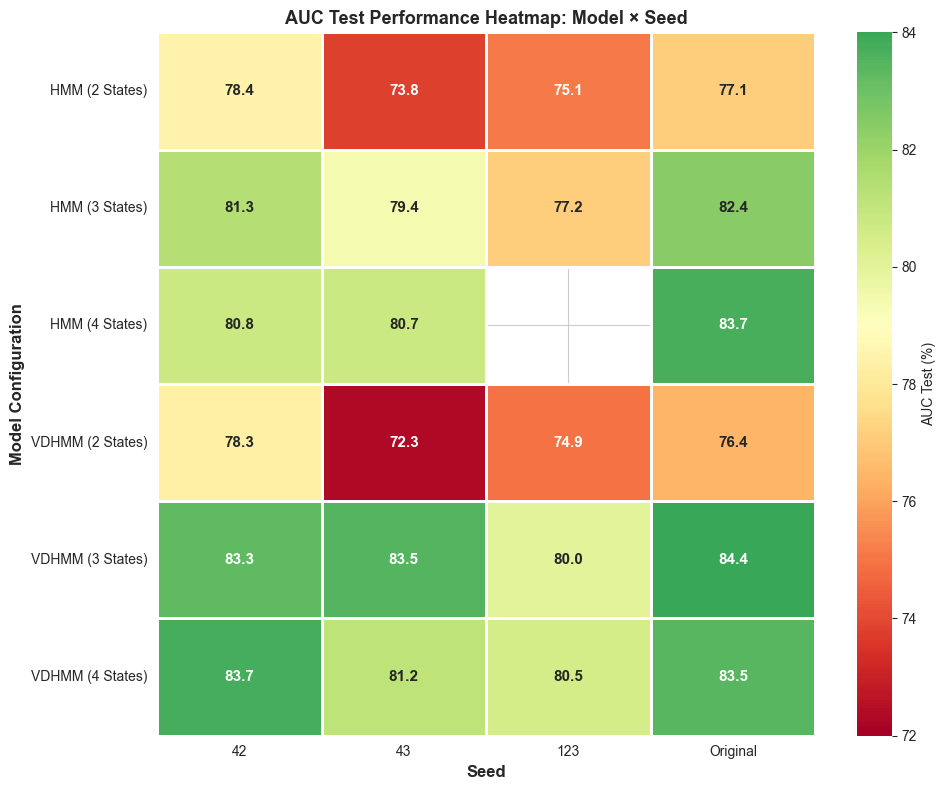

In [86]:
fig, ax = plt.subplots(figsize=(10, 8))

# Pivot table for heatmap
pivot_data = robustness_df.pivot_table(
    values="AUC_TEST", index=["Model_Type", "States"], columns="Seed"
)

# Create labels
row_labels = [f"{mt} ({s} States)" for mt, s in pivot_data.index]

sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=79,
    vmin=72,
    vmax=84,
    cbar_kws={"label": "AUC Test (%)"},
    yticklabels=row_labels,
    ax=ax,
    linewidths=1,
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)

ax.set_xlabel("Seed", fontsize=12, fontweight="bold")
ax.set_ylabel("Model Configuration", fontsize=12, fontweight="bold")
ax.set_title(
    "AUC Test Performance Heatmap: Model × Seed", fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [87]:
# Robustness summary
print("=" * 100)
print("ROBUSTNESS SUMMARY: Top 3 Most Robust Models")
print("=" * 100)

top3_robust = robustness_ranking.head(3)

for i, (idx, row) in enumerate(top3_robust.iterrows(), 1):
    print(f"\n{i}. {row['Model_Type']} ({row['States']} States)")
    print(f"   - Mean AUC Test: {row['AUC_TEST_mean']:.2f}%")
    print(f"   - Std: ±{row['AUC_TEST_std']:.2f}%")
    print(f"   - Coefficient of Variation (CV): {row['AUC_TEST_CV_%']:.2f}%")
    print(
        f"   - Range: {row['AUC_TEST_Range']:.2f}% (Min: {row['AUC_TEST_min']:.2f}%, Max: {row['AUC_TEST_max']:.2f}%)"
    )
    print(
        f"   - Mean R-hat: {row['R_HAT_MEAN_mean']:.4f} (Max: {row['R_HAT_MEAN_max']:.4f})"
    )

ROBUSTNESS SUMMARY: Top 3 Most Robust Models

1. VDHMM (4 States)
   - Mean AUC Test: 82.22%
   - Std: ±1.61%
   - Coefficient of Variation (CV): 1.96%
   - Range: 3.20% (Min: 80.52%, Max: 83.72%)
   - Mean R-hat: 1.6400 (Max: 1.8000)

2. HMM (4 States)
   - Mean AUC Test: 81.74%
   - Std: ±1.70%
   - Coefficient of Variation (CV): 2.08%
   - Range: 2.97% (Min: 80.74%, Max: 83.71%)
   - Mean R-hat: 1.5200 (Max: 1.6500)

3. VDHMM (3 States)
   - Mean AUC Test: 82.79%
   - Std: ±1.93%
   - Coefficient of Variation (CV): 2.33%
   - Range: 4.40% (Min: 79.99%, Max: 84.39%)
   - Mean R-hat: 1.2000 (Max: 1.7900)


# Signifikanz zwischen den Variable-Duration Hidden-Markov Models mit 3 und mit 4 Zuständen
